NAME: MINAL HONALI RAGHUNANDAN

STUDENT ID: 6908107

Project Overview: Create a music recommendation system based on emotion analysis
by using the DEAM dataset

Notebook 3: Recommendation Engine

Given a target mood (valence, arousal), this notebook retrieves the closest-matching
songs from the DEAM catalogue based on Euclidean distance in emotion space, using the
tuned XGBoost models' predicted coordinates for consistency across the full dataset.

In [16]:
#imports
import os
import glob
import pandas as pd
import numpy as np
import joblib
import re
from sklearn.model_selection import train_test_split
import kagglehub

from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [19]:
DATA_PATH = "/content/drive/MyDrive/Dissertation/data/processed"
MODEL_DIR = "/content/drive/MyDrive/Dissertation/models"

df_full = pd.read_csv(os.path.join(DATA_PATH, "deam_full_with_ids.csv"))

valence_mod = joblib.load(os.path.join(MODEL_DIR, "valence_model.pkl"))
arousal_mod = joblib.load(os.path.join(MODEL_DIR, "arousal_model.pkl"))
trained_cols = joblib.load(os.path.join(MODEL_DIR, "feature_columns.pkl"))
scaler = joblib.load(os.path.join(MODEL_DIR, "scaler.pkl"))

regx = re.compile(r"\[|\]|<")
raw_cols = [c for c in df_full.columns if c not in ["song_id", "valence_mean", "arousal_mean", "valence_norm", "arousal_norm"]]

sanitized_to_raw = {regx.sub("_", c): c for c in raw_cols}
raw_cols_ordered = [sanitized_to_raw[c] for c in trained_cols]

X_full_raw = df_full[raw_cols_ordered]
X_full_scaled_raw = pd.DataFrame(scaler.transform(X_full_raw), columns=raw_cols_ordered)

X_full_scaled = X_full_scaled_raw.rename(columns=lambda c: regx.sub("_", c))
X_full_scaled = X_full_scaled[trained_cols]

pred_valence = valence_mod.predict(X_full_scaled)
pred_arousal = arousal_mod.predict(X_full_scaled)

song_pool = pd.DataFrame({
    "song_id": df_full["song_id"],
    "pred_valence": pred_valence,
    "pred_arousal": pred_arousal
})

print(f"Recommendation pool ready: {len(song_pool)} songs")
song_pool.head()

Recommendation pool ready: 1744 songs


,song_id,pred_valence,pred_arousal
0,2,-0.466741,-0.380979
1,3,-0.376419,-0.352446
2,4,0.172127,0.073472
3,5,-0.150542,-0.004510
4,7,0.200146,0.275089


In [20]:
MOOD_TARGETS = {
    "excited_elated": (0.75, 0.75),
    "angry_stressed" : (-0.75,0.75),
    "sad_depressed" : (-0.75,-0.75),
    "calm_relaxed" : (0.75,-0.75),
    "content_serene": (0.85,-0.65),
    "bored_tired": (-0.30,-0.70),
}

def rec_songs(target_val, target_aro, n=5,exclude_song_id=None):
  pool = song_pool.copy()
  if exclude_song_id is not None:
    pool = pool[pool["song_id"] != exclude_song_id]
  pool["dist"] = np.sqrt(
      (pool["pred_valence"]-target_val)**2 + (pool["pred_arousal"]-target_aro)**2
  )
  return pool.sort_values("dist").head(n).reset_index(drop=True)

def rec_by_mood(mood, n=5):
  v, a = MOOD_TARGETS[mood]
  return rec_songs(v, a, n=n)

for mood in MOOD_TARGETS:
  recs = rec_by_mood(mood, n=5)
  print(f"{mood}:{recs['song_id'].tolist()}")

excited_elated:[115, 960, 343, 1398, 477]
angry_stressed:[1903, 1334, 1993, 1964, 1948]
sad_depressed:[236, 1332, 133, 660, 310]
calm_relaxed:[702, 253, 893, 631, 939]
content_serene:[702, 893, 631, 253, 902]
bored_tired:[1121, 1186, 1405, 1210, 1171]


In [26]:
!wget -q https://cvml.unige.ch/databases/DEAM/metadata.zip -O /content/deam_metadata.zip
!unzip -o -q /content/deam_metadata.zip -d /content/deam_metadata

meta_files = glob.glob("/content/deam_metadata/**/*.csv", recursive=True)
print(f"Found {len(meta_files)} metadata files")

Found 3 metadata files


In [22]:
!ls -la /content/deam_metadata.zip
!find /content/deam_metadata -type f | head -20

-rw-r--r-- 1 root root 344760 Jul 25  2016 /content/deam_metadata.zip
/content/deam_metadata/metadata/metadata_2014.csv
/content/deam_metadata/metadata/metadata_2013.csv
/content/deam_metadata/metadata/metadata_2015.csv


In [28]:
def load_meta(path):
    df = pd.read_csv(path, on_bad_lines='skip', engine='python', index_col=False)
    df.columns = [c.strip() for c in df.columns]
    rename_map = {}
    for c in df.columns:
        cl = c.lower()
        if cl in ('song_id', 'id'):
            rename_map[c] = 'song_id'
        elif cl in ('song title', 'track', 'title'):
            rename_map[c] = 'title'
        elif cl == 'artist':
            rename_map[c] = 'Artist'
        elif cl == 'genre':
            rename_map[c] = 'Genre'
    df = df.rename(columns=rename_map)
    keep = [c for c in ['song_id', 'Artist', 'title', 'Genre'] if c in df.columns]
    df = df[keep]
    for c in df.columns:
        if df[c].dtype == object:
            df[c] = df[c].astype(str).str.replace('\t', '', regex=False).str.strip()
    return df

meta_all = pd.concat([load_meta(f) for f in meta_files], ignore_index=True)
meta_all['song_id'] = pd.to_numeric(meta_all['song_id'], errors='coerce')
meta_all = meta_all.dropna(subset=['song_id'])
meta_all['song_id'] = meta_all['song_id'].astype(int)
meta_all = meta_all.drop_duplicates(subset=['song_id'], keep='first')

print(f"Metadata rows: {len(meta_all)}")

song_pool = song_pool.drop(columns=[c for c in ['Artist','title','Genre'] if c in song_pool.columns])
song_pool = song_pool.merge(meta_all, on='song_id', how='left')
print(f"Matched titles: {song_pool['title'].notna().sum()}/{len(song_pool)}")
song_pool.head()

Metadata rows: 1802
Matched titles: 1744/1744


/tmp/ipykernel_7188/3697622110.py:2: ParserWarning: Length of header or names does not match length of data. This leads to a loss of data with index_col=False.
  df = pd.read_csv(path, on_bad_lines='skip', engine='python', index_col=False)
/tmp/ipykernel_7188/3697622110.py:2: ParserWarning: Length of header or names does not match length of data. This leads to a loss of data with index_col=False.
  df = pd.read_csv(path, on_bad_lines='skip', engine='python', index_col=False)


,song_id,pred_valence,pred_arousal,Artist,title,Genre
0,2,-0.466741,-0.380979,The New Mystikal Troubadours,Tonight A Lonely Century,Blues
1,3,-0.376419,-0.352446,Kevin MacLeod,DD Groove,Blues
2,4,0.172127,0.073472,Kevin MacLeod,Slow Burn,Blues
3,5,-0.150542,-0.004510,My Bubba & Mi,Nothing Much,Blues
4,7,0.200146,0.275089,Kevin MacLeod,Hustle,Blues


In [27]:
files_2014 = [f for f in meta_files if "2014" in f][0]
files_2015 = [f for f in meta_files if "2015" in f][0]
df14 = pd.read_csv(files_2014, on_bad_lines='skip', engine='python')
df15 = pd.read_csv(files_2015, on_bad_lines='skip', engine='python')

print(df14.columns.tolist())
print(df15.columns.tolist())
df14.head(3)
df15.head(3)

['Id', 'Artist', 'Album', 'Track', 'Genre', 'segment start', 'segment end', 'last.fm labels']
['id', 'Filename', 'title', 'artist', 'album', 'genre', 'Unnamed: 6']


,id,Filename,title,artist,album,genre,Unnamed: 6
0,2001,Creepoid_OldTree,Old Tree,Creepoid,NaN,Rock,NaN
1,2002,AmarLal_SpringDay1,Spring Day 1,Amar Lal,NaN,Singer/Songwriter,NaN
2,2003,JoelHelander_ExcessiveResistancetoChange,Excessive Resistance to Change,Joel Helander,NaN,Classical,NaN


In [30]:
song_pool.to_csv(os.path.join(DATA_PATH, "song_pool_predictions.csv"), index=False)
print("Saved")

for mood in MOOD_TARGETS:
    recs = rec_by_mood(mood, n=3)
    print(f"\n{mood}:")
    print(recs[['song_id','title','Artist','Genre','pred_valence','pred_arousal']].to_string(index=False))

Saved

excited_elated:
 song_id          title                             Artist   Genre  pred_valence  pred_arousal
     115    Bip Bop Bip Barrence Whitfield and The Savages   Blues      0.845900      0.588066
     960   Helix Nebula                       Anamanaguchi    Rock      0.671390      0.547316
     343 Clear Blue Sky                Chatham County Line Country      0.494766      0.639423

angry_stressed:
 song_id        title                    Artist      Genre  pred_valence  pred_arousal
    1903        dead. Violins is not the answer       Rock     -0.440100      0.460082
    1334         Eyes             I Have Clones Electronic     -0.293823      0.533427
    1993 InstruMental            The Metamatics       Rock     -0.363820      0.421520

sad_depressed:
 song_id                   title                     Artist      Genre  pred_valence  pred_arousal
     236 Transmutation Of Metals Chuck Bettis & Joe Merolla  Classical     -0.624583     -0.619862
    1332          

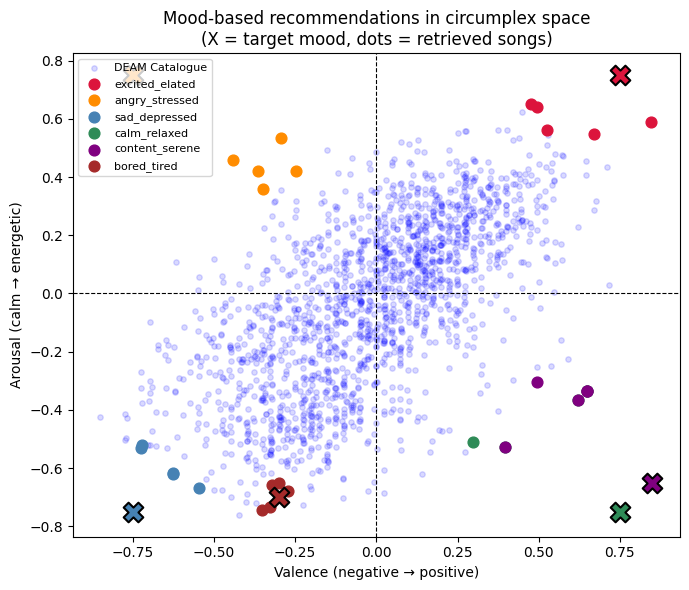

In [33]:
import matplotlib.pyplot as plt
plt.figure(figsize=(7,6))
plt.scatter(song_pool['pred_valence'], song_pool['pred_arousal'],
            alpha=0.15, color='blue', s=15, label= "DEAM Catalogue")
colors = ["crimson", "darkorange", "steelblue", "seagreen", "purple", "brown"]

for (mood, (v,a)), c in zip(MOOD_TARGETS.items(), colors):
  recs = rec_by_mood(mood, n=5)
  plt.scatter(recs["pred_valence"], recs["pred_arousal"], color=c, s=60, label=mood)
  plt.scatter(v, a, color=c, marker="X", s=200, edgecolors="black", linewidths=1.5)

plt.axhline(0, color="black", linestyle="--", linewidth=0.8)
plt.axvline(0, color="black", linestyle="--", linewidth=0.8)
plt.xlabel("Valence (negative → positive)")
plt.ylabel("Arousal (calm → energetic)")
plt.title("Mood-based recommendations in circumplex space\n(X = target mood, dots = retrieved songs)")
plt.legend(loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()



###NOTEBOOK SUMMARY

-  loading full DEAM dataset with song ids, trained models and scaler

- emotion prediction across 1744 songs

- DEAM metadata retrieval

- distance based recommendation function

- visualisation
